# CardioIA — Fase 2, Parte 2: classificador de risco por texto

Triagem simulada: dada uma frase em que o paciente descreve o que sente, o
modelo classifica o relato como **alto risco** ou **baixo risco**, para
priorizar o atendimento.

Roteiro do notebook:

1. Carregar a base rotulada (`frases_risco.csv`, 200 frases escritas pelo grupo)
2. Separar treino e teste
3. Vetorizar as frases com **TF-IDF**
4. Treinar dois modelos do scikit-learn: **Logistic Regression** e **Decision Tree**
5. Avaliar com acurácia, precisão, recall e matriz de confusão (mais validação cruzada)
6. Escolher o modelo e inspecionar o que ele aprendeu
7. Testar com **frases de risco diferente**, construídas para expor distorções
8. Discutir padrões, vieses e limitações

> Projeto acadêmico. Nenhuma saída deste modelo substitui avaliação médica.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             classification_report, ConfusionMatrixDisplay)

SEED = 42  # mesma semente da Fase 1: resultados reprodutíveis
pd.set_option("display.max_colwidth", 120)

## 1. Os dados

A base foi escrita à mão: 100 frases de **alto risco** e 100 de **baixo risco**.
O critério de rótulo segue os sinais de alarme usados em triagem:

- **alto risco**: dor ou aperto no peito (sobretudo com irradiação, suor frio,
  esforço ou duração prolongada), falta de ar súbita ou em repouso, desmaio,
  palpitação com tontura, sinais neurológicos, pressão muito alta com sintomas,
  inchaço com falta de ar;
- **baixo risco**: queixas leves, musculares, respiratórias altas, digestivas,
  ou sintomas com causa evidente que já passaram.

Algumas frases foram escritas de propósito para **não** serem triviais. Há
frases de baixo risco que mencionam o peito ("peito dolorido quando aperto,
depois do supino") e frases de alto risco que não mencionam ("desmaiei duas
vezes hoje"). Sem elas, o modelo aprenderia só que "peito" significa alto risco.

In [2]:
dados = pd.read_csv("frases_risco.csv")
print(dados.shape)
print(dados["situacao"].value_counts())
dados.sample(8, random_state=SEED)

(200, 2)
situacao
alto risco     100
baixo risco    100
Name: count, dtype: int64


,frase,situacao
95,tenho prisão de ventre há três dias,baixo risco
15,sinto coceira na pele depois de usar um sabonete novo,baixo risco
30,sinto um peso enorme no tórax desde que acordei,alto risco
158,a dor no peito vem junto com falta de ar e fraqueza nas pernas,alto risco
128,tive convulsão e agora meu coração está muito acelerado,alto risco
115,sinto as mãos frias quando o dia está gelado,baixo risco
69,"meu nariz sangrou um pouco depois de assoar com força, e já parou",baixo risco
170,o coração disparou do nada e não para há mais de uma hora,alto risco


In [3]:
# Variável alvo binária: 1 = alto risco (a classe que não podemos deixar escapar)
X = dados["frase"]
y = (dados["situacao"] == "alto risco").astype(int)

## 2. Treino e teste

75% das frases para treino e 25% (50 frases) para teste. A divisão é
**estratificada**, para manter 50/50 de cada classe nos dois conjuntos.

O TF-IDF é ajustado **só no treino**, dentro do `Pipeline`. Se o vocabulário
fosse calculado com a base inteira, informação do teste vazaria para o treino.

In [4]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=SEED)
print(f"treino: {len(X_treino)} frases | teste: {len(X_teste)} frases")

treino: 150 frases | teste: 50 frases


## 3. TF-IDF: de frase para vetor

O modelo não lê texto, só números. O TF-IDF transforma cada frase em um vetor
com uma posição por termo do vocabulário:

- **TF** (frequência do termo): quantas vezes o termo aparece na frase;
- **IDF** (inverso da frequência nos documentos): termos que aparecem em
  quase todas as frases ("estou", "com") pesam pouco, e termos raros e
  informativos ("irradia", "desmaiei") pesam muito.

Escolhas de configuração:

| Parâmetro | Valor | Motivo |
|---|---|---|
| `strip_accents` | `"unicode"` | "coração" e "coracao" viram o mesmo termo |
| `ngram_range` | `(1, 2)` | além de palavras soltas, pares como "dor peito" e "falta ar" carregam contexto |
| `stop_words` | **nenhuma** | listas de stopwords em português removem "não", "sem" e "nem", e com isso "não sinto dor no peito" viraria "sinto dor peito" |

In [5]:
tfidf_demo = TfidfVectorizer(strip_accents="unicode", ngram_range=(1, 2)).fit(X_treino)
print("tamanho do vocabulário:", len(tfidf_demo.vocabulary_))

exemplo = "sinto dor no peito e falta de ar"
vetor = tfidf_demo.transform([exemplo])
termos = tfidf_demo.get_feature_names_out()
pesos = pd.Series(vetor.toarray()[0], index=termos)
print(f"\n'{exemplo}' tem {vetor.nnz} posições não nulas, de {vetor.shape[1]}:")
pesos[pesos > 0].sort_values(ascending=False).round(3)

tamanho do vocabulário: 1393

'sinto dor no peito e falta de ar' tem 12 posições não nulas, de 1393:


sinto dor    0.417
de ar        0.342
falta        0.342
falta de     0.342
ar           0.313
dor no       0.301
no peito     0.261
peito        0.233
sinto        0.220
dor          0.215
no           0.192
de           0.183
dtype: float64

## 4. Dois modelos

- **Logistic Regression**: modelo linear. Cada termo recebe um peso positivo
  (empurra para alto risco) ou negativo (empurra para baixo risco). Lida bem
  com vetores esparsos e de muitas dimensões, como os do TF-IDF.
- **Decision Tree**: uma sequência de perguntas "o termo X aparece?". Fácil de
  explicar, mas com 150 frases de treino tende a decorar termos específicos.

In [6]:
def novo_tfidf():
    return TfidfVectorizer(strip_accents="unicode", ngram_range=(1, 2))

modelos = {
    "Logistic Regression": Pipeline([("tfidf", novo_tfidf()),
                                     ("clf", LogisticRegression(max_iter=1000, random_state=SEED))]),
    "Decision Tree": Pipeline([("tfidf", novo_tfidf()),
                               ("clf", DecisionTreeClassifier(random_state=SEED))]),
}
for nome, modelo in modelos.items():
    modelo.fit(X_treino, y_treino)
    print(f"{nome}: treinado")

Logistic Regression: treinado
Decision Tree: treinado


## 5. Avaliação no conjunto de teste

A acurácia sozinha não basta em triagem. Os dois erros possíveis têm custos
muito diferentes:

- **falso positivo** (baixo risco classificado como alto): o paciente é
  atendido antes do necessário. Custa tempo de fila.
- **falso negativo** (alto risco classificado como baixo): um possível infarto
  vai para o fim da fila. Pode custar uma vida.

Por isso a métrica principal aqui é o **recall de alto risco**: de todos os
pacientes realmente graves, quantos o modelo sinalizou.

In [7]:
linhas = []
for nome, modelo in modelos.items():
    pred = modelo.predict(X_teste)
    linhas.append({
        "modelo": nome,
        "acurácia": accuracy_score(y_teste, pred),
        "precisão (alto)": precision_score(y_teste, pred),
        "recall (alto)": recall_score(y_teste, pred),
        "falsos negativos": int(((y_teste == 1) & (pred == 0)).sum()),
    })
pd.DataFrame(linhas).set_index("modelo").round(3)

,acurácia,precisão (alto),recall (alto),falsos negativos
modelo,,,,
Logistic Regression,0.84,0.840,0.84,4
Decision Tree,0.74,0.731,0.76,6


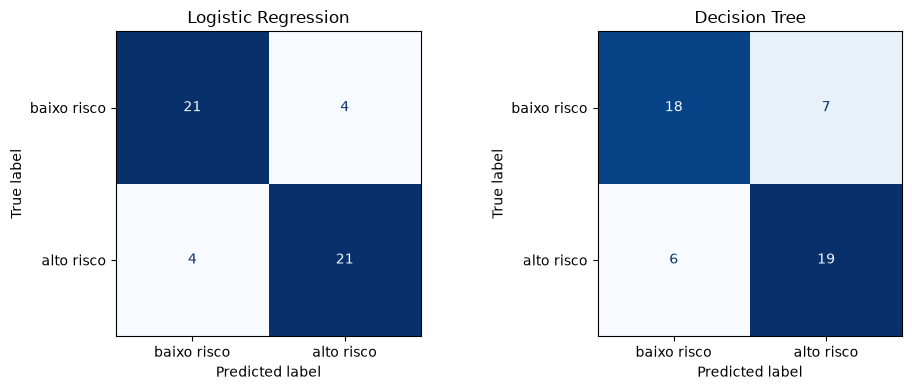

=== Logistic Regression ===
              precision    recall  f1-score   support

 baixo risco      0.840     0.840     0.840        25
  alto risco      0.840     0.840     0.840        25

    accuracy                          0.840        50
   macro avg      0.840     0.840     0.840        50
weighted avg      0.840     0.840     0.840        50

=== Decision Tree ===
              precision    recall  f1-score   support

 baixo risco      0.750     0.720     0.735        25
  alto risco      0.731     0.760     0.745        25

    accuracy                          0.740        50
   macro avg      0.740     0.740     0.740        50
weighted avg      0.740     0.740     0.740        50



In [8]:
rotulos = ["baixo risco", "alto risco"]
fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
for eixo, (nome, modelo) in zip(eixos, modelos.items()):
    ConfusionMatrixDisplay.from_estimator(modelo, X_teste, y_teste, display_labels=rotulos,
                                          cmap="Blues", colorbar=False, ax=eixo)
    eixo.set_title(nome)
plt.tight_layout()
plt.show()

for nome, modelo in modelos.items():
    print(f"=== {nome} ===")
    print(classification_report(y_teste, modelo.predict(X_teste), target_names=rotulos, digits=3))

### Validação cruzada

Com só 50 frases de teste, cada frase vale 2 pontos percentuais de acurácia, e
o resultado depende muito de quais frases caíram no teste. A validação cruzada
estratificada em 5 partes treina e testa 5 vezes, cada vez com um bloco
diferente como teste, e reporta média e desvio. É uma estimativa bem mais
estável.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
linhas = []
for nome, modelo in modelos.items():
    r = cross_validate(modelo, X, y, cv=cv, scoring=["accuracy", "recall"])
    linhas.append({
        "modelo": nome,
        "acurácia (média)": r["test_accuracy"].mean(),
        "acurácia (desvio)": r["test_accuracy"].std(),
        "recall alto (média)": r["test_recall"].mean(),
        "recall alto (desvio)": r["test_recall"].std(),
    })
pd.DataFrame(linhas).set_index("modelo").round(3)

,acurácia (média),acurácia (desvio),recall alto (média),recall alto (desvio)
modelo,,,,
Logistic Regression,0.870,0.053,0.86,0.066
Decision Tree,0.755,0.043,0.65,0.164


## 6. Escolha do modelo: Logistic Regression

A Logistic Regression é superior nas duas métricas que importam, tanto no
teste quanto na validação cruzada. A diferença é maior justamente no **recall
de alto risco**, ou seja, a árvore deixa passar mais pacientes graves.

A explicação está no formato dos dados. Cada frase ativa poucos termos entre
centenas, e o mesmo conceito aparece com palavras diferentes ("falta de ar",
"sem fôlego", "ofegante"). A regressão logística soma pequenas evidências de
muitos termos. A árvore precisa escolher uma pergunta por vez e, com poucos
exemplos, decora termos que só apareceram no treino.

A regressão logística tem outra vantagem: dá para **ler** o que ela aprendeu.

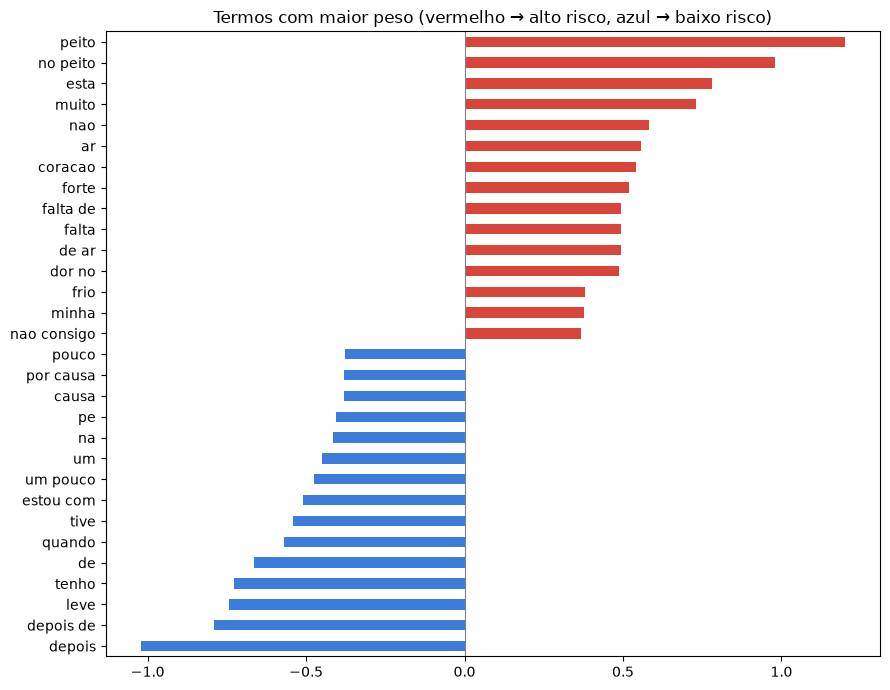

In [10]:
modelo = modelos["Logistic Regression"]
termos = modelo.named_steps["tfidf"].get_feature_names_out()
coefs = pd.Series(modelo.named_steps["clf"].coef_[0], index=termos).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
extremos = pd.concat([coefs.head(15), coefs.tail(15)])
cores = ["#3b7dd8" if c < 0 else "#d8463b" for c in extremos]
extremos.plot.barh(ax=ax, color=cores)
ax.set_title("Termos com maior peso (vermelho → alto risco, azul → baixo risco)")
ax.axvline(0, color="gray", lw=0.8)
plt.tight_layout()
plt.show()

## 7. Frases de risco diferente: procurando distorções

O teste acima usa frases no **mesmo estilo** das de treino, porque foram
escritas pelas mesmas pessoas. Isso superestima o desempenho real. Para ver
como o modelo se comporta com relatos diferentes, montamos
`frases_adversariais.csv`: 20 frases fora do padrão, agrupadas pelo tipo de
armadilha.

| Tipo | O que testa |
|---|---|
| negação | "**não** sinto dor no peito" deveria ser baixo risco |
| intensidade atenuada | "dor **leve** no peito" ainda é alto risco |
| termo técnico | "dispneia", "síncope", "precordialgia" não estão no vocabulário |
| linguagem coloquial | "coração saindo pela boca" |
| contexto familiar | "meu **pai** teve infarto, mas eu estou bem" |
| erro de digitação | "dor no peitu" |
| grave sem termo óbvio | sinais graves descritos sem as palavras usuais |
| termo alarmante em contexto leve | "dor no peito depois de uma bolada, já passou" |
| apresentação atípica | idosos e mulheres, que costumam relatar infarto como cansaço ou enjoo |

In [11]:
adv = pd.read_csv("frases_adversariais.csv")
y_adv = (adv["situacao_esperada"] == "alto risco").astype(int)

for nome, m in modelos.items():
    curto = "LR" if nome.startswith("Logistic") else "DT"
    adv[f"pred_{curto}"] = np.where(m.predict(adv["frase"]) == 1, "alto risco", "baixo risco")
adv["P(alto)_LR"] = modelos["Logistic Regression"].predict_proba(adv["frase"])[:, 1].round(2)
adv["LR_acertou"] = adv["pred_LR"] == adv["situacao_esperada"]
adv[["tipo", "frase", "situacao_esperada", "pred_LR", "P(alto)_LR", "pred_DT"]]

,tipo,frase,situacao_esperada,pred_LR,P(alto)_LR,pred_DT
0,negação,"não sinto dor no peito nem falta de ar, só um pouco de coceira",baixo risco,alto risco,0.63,alto risco
1,negação,"não tenho falta de ar, só vim renovar a receita",baixo risco,alto risco,0.57,alto risco
2,negação,"nunca desmaiei, mas estou com dor de garganta",baixo risco,baixo risco,0.33,baixo risco
3,intensidade atenuada,sinto uma dor leve no peito e um pouco de falta de ar,alto risco,alto risco,0.53,alto risco
4,intensidade atenuada,tenho um leve aperto no peito que vai para o braço,alto risco,alto risco,0.58,alto risco
5,termo técnico,apresento precordialgia em opressão há quarenta minutos,alto risco,alto risco,0.51,baixo risco
6,termo técnico,estou com dispneia súbita e sudorese,alto risco,baixo risco,0.45,baixo risco
7,termo técnico,tive uma síncope hoje cedo,alto risco,baixo risco,0.42,baixo risco
8,linguagem coloquial,tô com o coração saindo pela boca e a vista apagando,alto risco,alto risco,0.55,baixo risco
9,linguagem coloquial,deu um troço no peito e o braço ficou mole,alto risco,alto risco,0.62,alto risco


In [12]:
resumo = []
for nome, m in modelos.items():
    pred = m.predict(adv["frase"])
    resumo.append({
        "modelo": nome,
        "acurácia (adversarial)": accuracy_score(y_adv, pred),
        "recall alto (adversarial)": recall_score(y_adv, pred),
        "falsos negativos": int(((y_adv == 1) & (pred == 0)).sum()),
        "falsos positivos": int(((y_adv == 0) & (pred == 1)).sum()),
    })
display(pd.DataFrame(resumo).set_index("modelo").round(3))

print("Acertos da Logistic Regression por tipo de armadilha:")
adv.groupby("tipo")["LR_acertou"].agg(["sum", "count"]).rename(columns={"sum": "acertos", "count": "frases"})

,acurácia (adversarial),recall alto (adversarial),falsos negativos,falsos positivos
modelo,,,,
Logistic Regression,0.60,0.769,3,5
Decision Tree,0.65,0.692,4,3


Acertos da Logistic Regression por tipo de armadilha:


,acertos,frases
tipo,,
apresentação atípica,1,2
contexto familiar,1,2
erro de digitação,2,2
grave sem termo óbvio,2,2
intensidade atenuada,2,2
linguagem coloquial,2,2
negação,1,3
termo alarmante em contexto leve,0,2
termo técnico,1,3


In [13]:
# Os erros no conjunto de teste regular também ensinam
pred_teste = modelo.predict(X_teste)
proba_teste = modelo.predict_proba(X_teste)[:, 1]
erros = pd.DataFrame({"frase": X_teste, "real": y_teste, "previsto": pred_teste,
                      "P(alto)": proba_teste.round(2)})[y_teste != pred_teste]
erros["real"] = erros["real"].map({1: "alto risco", 0: "baixo risco"})
erros["previsto"] = erros["previsto"].map({1: "alto risco", 0: "baixo risco"})
erros

,frase,real,previsto,P(alto)
121,meu bebê está com assadura,baixo risco,alto risco,0.65
86,tenho histórico de infarto e a dor voltou igual à da outra vez,alto risco,baixo risco,0.43
122,tenho uma dor em aperto atrás do esterno que dura mais de quinze minutos,alto risco,baixo risco,0.49
154,tenho palpitação constante e já desmaiei uma vez esta semana,alto risco,baixo risco,0.50
75,"sinto o coração acelerar quando tomo muito café, mas passa rápido",baixo risco,alto risco,0.59
115,sinto as mãos frias quando o dia está gelado,baixo risco,alto risco,0.54
185,meu filho está com piolho,baixo risco,alto risco,0.65
44,estou com o lábio arroxeado e respirando com dificuldade,alto risco,baixo risco,0.45


## 8. Padrões e distorções encontrados

Os números acima parecem bons: **87% de acurácia** e **86% de recall de alto
risco** na validação cruzada. Os coeficientes e as frases adversariais mostram
que parte desse desempenho vem de **atalhos** que o modelo encontrou no jeito
como o grupo escreveu as frases, e não de entendimento clínico.

### 8.1 O modelo aprendeu o estilo de escrita, não só os sintomas

| Termo | Peso | Por que o modelo aprendeu isso |
|---|---|---|
| `nao` | **+0,58** | Nas frases graves, "não" aparece em "**não** passa", "**não** consigo respirar", "**não** melhorou". O modelo aprendeu que "não" indica gravidade, então **negar um sintoma aumenta o risco**. |
| `esta` | **+0,78** | "está" (sem acento vira "esta") aparece mais em relatos agudos ("meu peito **está** apertado"). É um artefato de redação. |
| `muito` | +0,73 | Intensificador. Faz algum sentido clínico, mas o modelo não sabe **o que** está "muito". |
| `tenho` / `tive` | **−0,73** / −0,54 | As frases leves foram escritas mais vezes com "tenho"/"tive" ("tenho caspa", "tive azia"). |
| `depois` | **−1,02** | As frases leves costumam explicar a causa ("dor na perna **depois** da corrida"). |
| `meu` / `minha` | +0,36 / +0,38 | 4 das 6 frases da base que começam falando de um familiar ("meu marido", "minha mãe idosa") são de alto risco. |
| `dor` | −0,03 | Isolada, "dor" não diz nada: aparece nas duas classes. O que pesa é **onde** dói (`peito` = +1,20). |

Esses artefatos explicam os erros concretos:

- **Dos 4 falsos negativos do teste, 3 começam com "tenho"**:
  "**tenho** histórico de infarto e a dor voltou", "**tenho** uma dor em aperto
  atrás do esterno…", "**tenho** palpitação constante e já desmaiei". São
  pacientes graves rebaixados por um verbo.
- **Falsos alarmes com "está" e "meu"**: "**meu** bebê **está** com assadura",
  "**meu** filho **está** com piolho" e "sinto as mãos frias quando o dia
  **está** gelado" foram classificados como alto risco.
- **Negação invertida**: "**não** sinto dor no peito, só uma coceira no braço"
  sai como **alto risco** (P = 0,64). O TF-IDF é um *saco de palavras*: vê
  "não", "dor", "peito" e soma, sem saber que o "não" se refere à dor.

### 8.2 O que as frases adversariais mostraram

| Tipo de armadilha | Resultado (LR) | Leitura |
|---|---|---|
| erro de digitação, coloquial, intensidade atenuada, grave sem termo óbvio | 8 de 8 | Funcionou porque ainda havia **outras** palavras conhecidas ("falta de ar", "peito", "frio") para sustentar a decisão. |
| termo técnico | 1 de 3 | "dispneia", "síncope" e "sudorese" **não existem no vocabulário**. Para o modelo, a frase é vazia. Um médico escrevendo no prontuário seria mal triado. |
| negação | 1 de 3 | Ver 8.1: o "não" empurra para alto risco. |
| termo alarmante em contexto leve | **0 de 2** | "dor no peito depois de uma **bolada**, já passou": `peito` domina, e o contexto é ignorado. |
| contexto familiar | 1 de 2 | "minha **tia** tem insuficiência cardíaca" → alto risco. O modelo não distingue quem tem o sintoma. |
| apresentação atípica | 1 de 2 | "tenho 80 anos e estou **só** muito cansada e enjoada" → baixo risco. |

O último caso é o mais importante do ponto de vista de **justiça**. Mulheres e
idosos apresentam infarto com mais frequência como cansaço, enjoo ou mal-estar,
sem a "dor no peito clássica". Um modelo que aprendeu que `peito` é o termo
mais forte **sub-tria justamente esses grupos**. É o mesmo viés de sexo e idade
medido na base clínica da Fase 1 (ver `fase1/docs/VIESES.md`), agora
reaparecendo no texto.

Na Decision Tree, a acurácia adversarial é ligeiramente maior (65% contra
60%), mas ela deixa passar **mais** pacientes graves (4 falsos negativos contra
3). Com 20 frases, a diferença de acurácia não é significativa. O recall é o
critério que mantém a escolha da Logistic Regression.

### 8.3 Por que isso acontece e como mitigar

A causa de fundo é que **200 frases escritas por duas pessoas** carregam o
estilo dessas duas pessoas. Com 1.393 termos e 150 frases de treino, há muito
mais termos do que exemplos, e qualquer coincidência de redação vira "padrão".
A acurácia de 87% mede o quanto o modelo reconhece **o nosso jeito de
escrever**, não o quanto ele triaria bem um paciente real.

Mitigações, da mais simples para a mais robusta:

1. **Tratar negação antes do TF-IDF**, marcando as palavras negadas
   (`não sinto dor` → `não sinto NEG_dor`). É a mesma regra de janela usada na
   Parte 1.
2. **Normalizar sinônimos** com o mapa de conhecimento da Parte 1 ("dispneia",
   "sem fôlego", "ofegante" → `falta_de_ar`), para o vocabulário técnico não
   cair fora do modelo.
3. **Regras de bandeira vermelha acima do modelo**: se a frase contém um sinal
   de alarme do mapa (peso 3), ela é alto risco independentemente da
   probabilidade. O modelo só decide os casos sem sinal claro.
4. **Ajustar o limiar de decisão** abaixo de 0,5 para favorecer o recall:
   aceitar mais falsos alarmes em troca de menos pacientes graves esquecidos.
5. **Dados mais diversos**: relatos escritos por várias pessoas, de idades,
   regiões e registros diferentes, com representação explícita de
   apresentações atípicas (mulheres, idosos, diabéticos).
6. **Humano no circuito**: o modelo só **ordena a fila**. A classificação
   final é sempre de um profissional de saúde.

### 8.4 Conclusão

Um código simples (TF-IDF + regressão logística) chega a 87% de acurácia com
poucas linhas, e é isso que torna esse tipo de sistema atraente. O mesmo
modelo, porém, classifica "não sinto dor no peito" como urgente e rebaixa um
paciente com histórico de infarto por causa do verbo "tenho". A acurácia não
mostra nenhum dos dois problemas: eles só aparecem quando se olha **o que** o
modelo aprendeu e **com quem** ele erra. Antes de qualquer uso clínico, esse é
o trabalho que precisa ser feito.


## 9. Demonstração

Função de uso direto, para testar frases novas.

In [14]:
def classificar(frase: str) -> str:
    p = modelo.predict_proba([frase])[0, 1]
    rotulo = "ALTO RISCO" if p >= 0.5 else "baixo risco"
    return f"{rotulo:<12} P(alto)={p:.2f}  | {frase}"

for frase in [
    "estou com um aperto no peito que vai para o braço e suando frio",
    "tive uma leve dor nas costas depois de dormir de mau jeito",
    "de repente fiquei sem ar e com o coração disparado",
    "estou espirrando e com o nariz escorrendo",
    "não sinto dor no peito, só uma coceira no braço",
]:
    print(classificar(frase))

ALTO RISCO   P(alto)=0.67  | estou com um aperto no peito que vai para o braço e suando frio
baixo risco  P(alto)=0.28  | tive uma leve dor nas costas depois de dormir de mau jeito
ALTO RISCO   P(alto)=0.62  | de repente fiquei sem ar e com o coração disparado
baixo risco  P(alto)=0.41  | estou espirrando e com o nariz escorrendo
ALTO RISCO   P(alto)=0.64  | não sinto dor no peito, só uma coceira no braço
